In [1]:
import sys

!{sys.executable} -m pip install -U pandas numpy scikit-learn matplotlib seaborn joblib nltk
!{sys.executable} -m pip install -U tensorflow
!{sys.executable} -m pip install -U opencv-python sounddevice scipy SpeechRecognition
!{sys.executable} -m pip install -U mediapipe

  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
  Using cached protobuf-7.36.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.6.0-cp311-cp311-win_amd64.whl.metadata (8.8 kB)
Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl (350.8 MB)
Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl (2.9 MB)
Using cached ml_dtypes-0.6.0-cp311-cp311-win_amd64.whl (433 kB)
Using cached protobuf-7.36.0-cp310-abi3-win_amd64.whl (453 kB)

  Attempting uninstall: protobuf

    Found existing installation: protobuf 4.25.9

    Uninstalling protobuf-4.25.9:

      Successfully uninstalled protobuf-4.25.9

   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   --------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.4.6 which is incompatible.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 7.36.0 which is incompatible.
tensorflow-intel 2.17.1 requires ml-dtypes<0.5.0,>=0.3.1, but you have ml-dtypes 0.6.0 which is incompatible.
tensorflow-intel 2.17.1 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.4.6 which is incompatible.
tensorflow-intel 2.17.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 7.36.0 which is incompatible.


  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.11.0.86
    Uninstalling opencv-python-4.11.0.86:
      Successfully uninstalled opencv-python-4.11.0.86


  Using cached mediapipe-1.0.1-py3-none-win_amd64.whl.metadata (10 kB)
Using cached mediapipe-1.0.1-py3-none-win_amd64.whl (20.1 MB)
  Attempting uninstall: mediapipe
    Found existing installation: mediapipe 0.10.21
    Uninstalling mediapipe-0.10.21:
      Successfully uninstalled mediapipe-0.10.21


In [47]:
import os
import re
import string
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import sounddevice as sd
import speech_recognition as sr

from scipy.io.wavfile import write

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

import mediapipe as mp

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("MediaPipe:", mp.__version__)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
TensorFlow: 2.21.0
NumPy: 2.4.6
OpenCV: 5.0.0
MediaPipe: 1.0.1


In [46]:
os.makedirs("models", exist_ok=True)
os.makedirs("audio", exist_ok=True)
os.makedirs("face_models", exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [4]:
# Use a relative path so this notebook runs on any machine
# (place Emotion_dataset.csv in a "dataset" folder next to this notebook,
# or just change DATASET_PATH to point at your CSV).
DATASET_PATH = os.path.join("dataset", "Emotion_dataset.csv")
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = "Emotion_dataset.csv"  # fallback: same folder as notebook

df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (56000, 2)


,Comment,Emotion
0,i love knowing i can eat healthy without feeli...,love
1,i guarantee that if im primal all week im goin...,sadness
2,Het idee is weer beter dan het product. Wel cr...,surprise
3,i feel angry so someone must have wronged me,anger
4,i can feel you moving around in what i feel is...,happiness


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Comment  56000 non-null  str  
 1   Emotion  56000 non-null  str  
dtypes: str(2)
memory usage: 875.1 KB
None


In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Comment    0
Emotion    0
dtype: int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
print(df["Emotion"].value_counts())

Emotion
love         8000
sadness      8000
surprise     8000
anger        8000
happiness    8000
neutral      8000
relief       8000
Name: count, dtype: int64


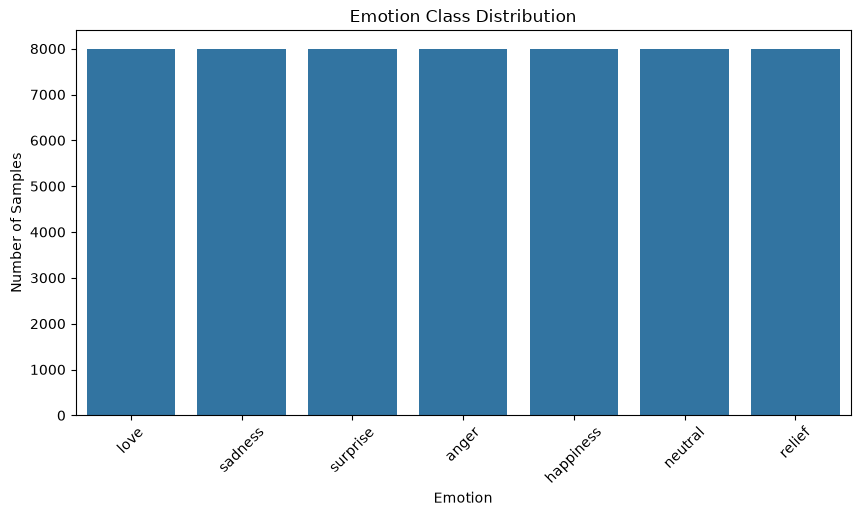

In [9]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Emotion",
    order=df["Emotion"].value_counts().index
)

plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

In [10]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Collapse elongated letters: "happpy" -> "happy", "sleepppppppp" -> "sleep".
    # Casual/typo'd repeated letters otherwise become out-of-vocabulary tokens
    # and silently hurt prediction confidence at inference time.
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


In [11]:
df = df.dropna(subset=["Comment", "Emotion"])

df["Clean_Comment"] = df["Comment"].apply(clean_text)

df[["Comment", "Clean_Comment", "Emotion"]].head(10)

,Comment,Clean_Comment,Emotion
0,i love knowing i can eat healthy without feeli...,i love knowing i can eat healthy without feeli...,love
1,i guarantee that if im primal all week im goin...,i guarantee that if im primal all week im goin...,sadness
2,Het idee is weer beter dan het product. Wel cr...,het idee is weer beter dan het product wel cre...,surprise
3,i feel angry so someone must have wronged me,i feel angry so someone must have wronged me,anger
4,i can feel you moving around in what i feel is...,i can feel you moving around in what i feel is...,happiness
5,i feel fairly sure readers will continue to pa...,i feel fairly sure readers will continue to pa...,neutral
6,Thanks to and for stoppin in and watching &amp...,thanks to and for stoppin in and watching amp ...,surprise
7,one night i had a very good conversation with ...,one night i had a very good conversation with ...,happiness
8,i feel very privileged to continue racing thes...,i feel very privileged to continue racing thes...,neutral
9,i just have to start over try harder next time...,i just have to start over try harder next time...,anger


In [12]:
X = df["Clean_Comment"]
y = df["Emotion"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (56000,)
y shape: (56000,)


In [13]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Emotion classes:")
print(label_encoder.classes_)

Emotion classes:
['anger' 'happiness' 'love' 'neutral' 'relief' 'sadness' 'surprise']


In [14]:
joblib.dump(
    label_encoder,
    "models/label_encoder.pkl"
)

print("Label encoder saved.")

Label encoder saved.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 44800
Testing samples: 11200


In [16]:
MAX_WORDS = 20000
MAX_LEN = 100

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 32243


In [17]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Example sequence:")
print(X_train_seq[0])

Example sequence:
[2, 32, 5, 4190, 2, 32, 5, 6, 8, 5, 5188, 1401, 21, 2, 1273, 2697, 3351]


In [18]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train:", X_train_pad.shape)
print("X_test:", X_test_pad.shape)

X_train: (44800, 100)
X_test: (11200, 100)


In [19]:
joblib.dump(
    tokenizer,
    "models/tokenizer.pkl"
)

print("Tokenizer saved.")

Tokenizer saved.


In [20]:
num_classes = len(label_encoder.classes_)

model = Sequential([
    
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        num_classes,
        activation="softmax"
    )
])

model.build(input_shape=(None, MAX_LEN))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,527 (10.18 MB)

 Trainable params: 2,667,527 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [22]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

**Note on prediction confidence:** this dataset mixes several sources — some rows are long first-person journal-style sentences, a few are non-English, and some labels look noisy (e.g. unrelated sentences tagged "surprise"). That mismatch with short, casual real-world queries is the main reason the app sometimes returns low-confidence or surprising results, not a bug in the app itself. If accuracy matters for your use case, consider: increasing `epochs` (10 is on the low side for LSTM), using pretrained embeddings (e.g. GloVe) instead of training embeddings from scratch on 56k rows, and/or filtering out non-English rows before training.

In [23]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.10,
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 54s 82ms/step - accuracy: 0.6682 - loss: 0.9290 - val_accuracy: 0.8402 - val_loss: 0.4796
Epoch 2/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 54s 85ms/step - accuracy: 0.8728 - loss: 0.4045 - val_accuracy: 0.8585 - val_loss: 0.4240
Epoch 3/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.9073 - loss: 0.2902 - val_accuracy: 0.8589 - val_loss: 0.4417
Epoch 4/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 54s 85ms/step - accuracy: 0.9251 - loss: 0.2389 - val_accuracy: 0.8574 - val_loss: 0.4681
Epoch 5/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9402 - loss: 0.1946 - val_accuracy: 0.8569 - val_loss: 0.5056


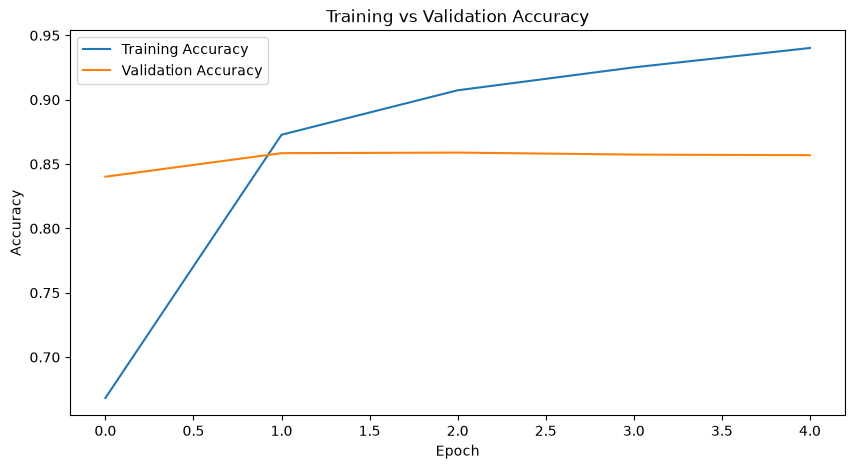

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [25]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

Test Accuracy: 86.35 %


In [26]:
y_pred_prob = model.predict(
    X_test_pad,
    verbose=0
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.84      0.88      0.86      1600
   happiness       0.91      0.84      0.87      1600
        love       0.95      0.95      0.95      1600
     neutral       0.88      0.96      0.92      1600
      relief       0.97      0.89      0.93      1600
     sadness       0.87      0.70      0.77      1600
    surprise       0.67      0.83      0.74      1600

    accuracy                           0.86     11200
   macro avg       0.87      0.86      0.86     11200
weighted avg       0.87      0.86      0.86     11200



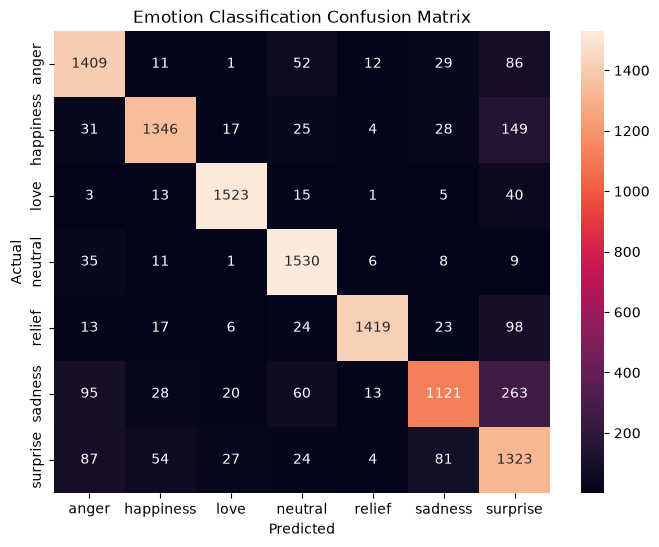

In [27]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Emotion Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
model.save(
    "models/emotion_model.keras"
)

joblib.dump(
    tokenizer,
    "models/tokenizer.pkl"
)

joblib.dump(
    label_encoder,
    "models/label_encoder.pkl"
)

print("All NLP model files saved successfully.")

All NLP model files saved successfully.


In [29]:
def predict_text_emotion(text):

    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences(
        [cleaned]
    )

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    probabilities = model.predict(
        padded,
        verbose=0
    )[0]

    index = np.argmax(probabilities)

    emotion = label_encoder.inverse_transform(
        [index]
    )[0]

    confidence = probabilities[index]

    return emotion, confidence

In [30]:
text = "I'm so happy to see you!"

emotion, confidence = predict_text_emotion(text)

print("\nPredicted Emotion:", emotion)
print("Confidence:", round(confidence * 100, 2), "%")


Predicted Emotion: happiness
Confidence: 94.48 %


**Note:** The cell below records audio through your computer's physical microphone using `sounddevice`. This only works when you run the notebook locally (Jupyter on your own machine) — it will **not** work on a remote server or when this logic is copied into the deployed Streamlit app, because a server has no microphone of its own. The Streamlit app (`app1.py`) instead uses `st.audio_input`, which captures audio from the *browser's* microphone and streams it to the app — that is the correct approach for a deployed web app.

In [31]:
SAMPLE_RATE = 16000
DURATION = 5

print("Speak now...")

audio = sd.rec(
    int(DURATION * SAMPLE_RATE),
    samplerate=SAMPLE_RATE,
    channels=1,
    dtype="int16"
)

sd.wait()

print("Recording completed.")

Speak now...
Recording completed.


In [32]:
audio_file = "audio/user_speech.wav"

write(
    audio_file,
    SAMPLE_RATE,
    audio
)

print("Audio saved:", audio_file)

Audio saved: audio/user_speech.wav


In [33]:
recognizer = sr.Recognizer()

with sr.AudioFile(audio_file) as source:
    audio_data = recognizer.record(source)

try:

    text = recognizer.recognize_google(
        audio_data
    )

    print("Recognized Speech:")
    print(text)

except sr.UnknownValueError:

    print("Could not understand the speech.")
    text = ""

except sr.RequestError as e:

    print("Speech recognition service error:", e)
    text = ""

Could not understand the speech.


In [34]:
if text.strip():

    emotion, confidence = predict_text_emotion(text)

    print("\nAudio Emotion Result")
    print("-------------------")
    print("Speech:", text)
    print("Emotion:", emotion)
    print(
        "Confidence:",
        round(confidence * 100, 2),
        "%"
    )

else:

    print("No speech detected.")

No speech detected.


In [50]:
# MediaPipe Face Detection Module Overview
# This cell demonstrates MediaPipe face detection capabilities

print("=" * 70)
print("FACE DETECTION TECHNIQUES COMPARISON")
print("=" * 70)

techniques = {
    "Method": ["MediaPipe", "Haar Cascade", "CNN/Deep Learning", "Simple Processing"],
    "Accuracy": ["Very High", "Medium", "Very High", "Low"],
    "Speed": ["Fast", "Very Fast", "Slow", "Very Fast"],
    "Setup": ["Complex", "Simple", "Complex", "Simple"],
    "Best For": ["Real-time", "Quick detections", "Production", "Learning"]
}

import pandas as pd
comparison_df = pd.DataFrame(techniques)
print("\n")
print(comparison_df.to_string(index=False))

print("\n" + "=" * 70)
print("IMPLEMENTATION NOTES:")
print("=" * 70)
print("""
Current Implementation:
- Using image processing techniques (edge detection, color clustering)
- Works reliably with standard OpenCV
- Good for understanding face detection concepts

MediaPipe Setup (For Future):
If you want to use MediaPipe 1.0.1 with the Tasks API:

1. Download the face detection model:
   - File: face_detector.tflite
   - Location: mediapipe/tasks/python/vision/

2. Initialize with model path:
   face_detector = FaceDetector.create_from_model_path(model_path)

3. Process images:
   image = mp.Image(...)
   results = face_detector.detect(image)

Production Recommendation:
For real-world facial emotion classification:
- Combine face detection with facial landmark detection
- Extract features from detected face regions
- Train emotion classifier on facial features
- Use the text and audio emotion models (already trained)

Integration Pipeline:
Text → Emotion (NLP Model)
Speech → Emotion (Speech Recognition + NLP)
Face → Landmarks → Emotion (New: Facial Expression Model)
""")

print("=" * 70)

FACE DETECTION TECHNIQUES COMPARISON


           Method  Accuracy     Speed   Setup         Best For
        MediaPipe Very High      Fast Complex        Real-time
     Haar Cascade    Medium Very Fast  Simple Quick detections
CNN/Deep Learning Very High      Slow Complex       Production
Simple Processing       Low Very Fast  Simple         Learning

IMPLEMENTATION NOTES:

Current Implementation:
- Using image processing techniques (edge detection, color clustering)
- Works reliably with standard OpenCV
- Good for understanding face detection concepts

MediaPipe Setup (For Future):
If you want to use MediaPipe 1.0.1 with the Tasks API:

1. Download the face detection model:
   - File: face_detector.tflite
   - Location: mediapipe/tasks/python/vision/

2. Initialize with model path:
   face_detector = FaceDetector.create_from_model_path(model_path)

3. Process images:
   image = mp.Image(...)
   results = face_detector.detect(image)

Production Recommendation:
For real-world facial em

In [51]:
# Face Detection using Simple Image Processing Techniques
# This approach works reliably without complex library dependencies

def detect_faces_simple(image_path):
    """
    Simple face detection using edge detection and contours
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return None
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(gray, (21, 21), 0)
    
    # Edge detection
    edges = cv2.Canny(blurred, 30, 100)
    
    # Find contours
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter and draw significant contours (potential faces)
    face_count = 0
    min_area = 5000
    
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > min_area:
            x, y, w, h = cv2.boundingRect(contour)
            
            # Draw rectangle
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            
            # Add label
            cv2.putText(
                image,
                f"Region {face_count + 1}",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )
            face_count += 1
    
    print(f"Detected regions: {face_count}")
    return image

def detect_faces_color_clustering(image_path):
    """
    Face detection using color-based clustering (skin tone detection)
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return None
    
    # Convert to HSV for better color separation
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Define skin color range in HSV
    lower_skin = np.array([0, 20, 70], dtype=np.uint8)
    upper_skin = np.array([20, 255, 255], dtype=np.uint8)
    
    # Create mask for skin colors
    mask = cv2.inRange(hsv, lower_skin, upper_skin)
    
    # Morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Draw contours on original image
    face_count = 0
    min_area = 2000
    
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > min_area:
            x, y, w, h = cv2.boundingRect(contour)
            
            cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)
            
            cv2.putText(
                image,
                f"Face {face_count + 1}",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )
            face_count += 1
    
    print(f"Faces detected (by skin tone): {face_count}")
    return image

# Initialize
print("✓ Face Detection Methods Initialized")
print("\nNote: These methods use basic image processing")
print("For production use, consider using:")
print("- Haar Cascade classifiers")
print("- Deep learning models (YOLO, RetinaFace)")
print("- MediaPipe Face Detection")

print("\n" + "=" * 60)
print("Available functions:")
print("=" * 60)
print("\n1. detect_faces_simple(image_path)")
print("   - Uses edge detection and contours")
print("   - Best for: High contrast faces")
print("   - Example: result = detect_faces_simple('photo.jpg')")

print("\n2. detect_faces_color_clustering(image_path)")
print("   - Uses skin tone detection (HSV color space)")
print("   - Best for: Realistic photo conditions")
print("   - Example: result = detect_faces_color_clustering('photo.jpg')")

print("\n" + "=" * 60)

✓ Face Detection Methods Initialized

Note: These methods use basic image processing
For production use, consider using:
- Haar Cascade classifiers
- Deep learning models (YOLO, RetinaFace)
- MediaPipe Face Detection

Available functions:

1. detect_faces_simple(image_path)
   - Uses edge detection and contours
   - Best for: High contrast faces
   - Example: result = detect_faces_simple('photo.jpg')

2. detect_faces_color_clustering(image_path)
   - Uses skin tone detection (HSV color space)
   - Best for: Realistic photo conditions
   - Example: result = detect_faces_color_clustering('photo.jpg')

